# ATP Tennis Match Analysis (2000–2026)
### Introduction to Python for data science project. Authors: Sofia Ostreikova & Ivan Shiryaev

## 1. Abstract / Annotation

This project analyzes a dataset of professional ATP (male) tennis matches played from 2000 to 2026. Each row is a single match and includes general information about itself, both players, betting odds. The aim of the project is to describe and visualize the data, cleanup invalid rows and prove two hypotheses:  

Does the betting favourite really win more often, and does that depend on the court surface?  
Does a bigger gap in ranking make the stronger player more likely to win, and is this effect larger in long best-of-5 matches than in short best-of-3 matches?  

### Distribution of contribution:
**Sofia Ostreikova:**  
- Data transformation  
- Detailed overview  
- Hypothesis 2  
- Discussion  
- POST endpoint  

**Ivan Shiryaev:**  
- Dataset description  
- Data cleanup  
- Descriptive statistics  
- Simple plots  
- Hypothesis 1  
- GET endpoint  


## 2. Dataset description

The data comes from the ATP Tour matches. It is published on Kaggle and it covers all matches from January 2000.

We start by importing all main modules, loading the file and looking at its shape, columns and their data types.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="darkgrid")

raw = pd.read_csv("atp_tennis.csv")

print("Rows and columns:", raw.shape)
raw.head()

Rows and columns: (67932, 17)


,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,-1,-1,-1.0,-1.0,6-3 6-7 4-6
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,-1,-1,-1.0,-1.0,4-6 6-7
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,-1,-1,-1.0,-1.0,3-6 3-6
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.0,-1.0,6-4 6-2
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,-1,-1,-1.0,-1.0,4-6 4-6


In [ ]:
print(raw.dtypes)

Tournament     object
Date           object
Series         object
Court          object
Surface        object
Round          object
Best of         int64
Player_1       object
Player_2       object
Winner         object
Rank_1          int64
Rank_2          int64
Pts_1           int64
Pts_2           int64
Odd_1         float64
Odd_2         float64
Score          object
dtype: object


The dataset has 17 columns. They can be split into 4 catefories:

| Category | Columns | Meaning |
|-------|---------|---------|
| Match context (text/categorical) | `Tournament`, `Date`, `Series`, `Court`, `Surface`, `Round`, `Best of` | where and how the match was played, how many sets |
| Players (text) | `Player_1`, `Player_2`, `Winner` | the two players and who won |
| Numbers | `Rank_1`, `Rank_2`, `Pts_1`, `Pts_2`, `Odd_1`, `Odd_2` | current ATP ranking, ranking points, and betting odds for each player |
| Result (text) | `Score` | set-by-set score, e.g. `6-3 6-7 4-6` |

A lower ranking number is better (rank 1 is the best player) and lower odds mean the bookmaker thinks that player is more likely to win (the favorite).

Let's check the data quality. We check for missing values (`NaN`).

In [ ]:
print("NaN values per column:")
print(raw.isna().sum())

NaN values per column:
Tournament    0
Date          0
Series        0
Court         0
Surface       0
Round         0
Best of       0
Player_1      0
Player_2      0
Winner        0
Rank_1        0
Rank_2        0
Pts_1         0
Pts_2         0
Odd_1         0
Odd_2         0
Score         0
dtype: int64


There are no `NaN` values and at first the data looks perfectly clean. But we can see that some data is stored as `-1`, but a ranking, points total, or odds value can never really be `-1`, so any `-1` means "value was missing". We count how often this missing value appears.

In [118]:
num_cols = ["Rank_1", "Rank_2", "Pts_1", "Pts_2", "Odd_1", "Odd_2"]

print("Values stored as -1:")
for c in num_cols:
    n = (raw[c] == -1).sum()
    print(f"{c}: {n} rows  ({100*n/len(raw):.1f}%)")

Values stored as -1:
Rank_1: 14 rows  (0.0%)
Rank_2: 12 rows  (0.0%)
Pts_1: 15652 rows  (23.0%)
Pts_2: 15653 rows  (23.0%)
Odd_1: 3782 rows  (5.6%)
Odd_2: 3780 rows  (5.6%)


So the data is not clean in reality:

- `Rank_1` and `Rank_2`: only a little bit of `-1` values (a few players had no ranking yet).
- `Odd_1` and `Odd_2`: about 6% of matches have no betting odds.
- `Pts_1` and `Pts_2`: about 23% of matches have no ranking points.

These `-1` would distort any average if we include them. We remove them in the **Data cleanup** section. There are no wrong data types except for the
`Date` column, which was given as plain text and we will convert it into a date format.

## 3. Descriptive statistics for the numerical fields

We summarize the numeric fields with mean, median, and standard deviation, minimum and maximum. Because `-1` are missing values, we temporarily replace them with `NaN` so they do not influence the averages and pandas will automatically skip `NaN`.

In [176]:
stats_view = raw.copy()
for c in num_cols:
    stats_view[c] = stats_view[c].replace(-1, np.nan)

summery = pd.DataFrame({
    "mean":   stats_view[num_cols].mean().round(2),
    "median": stats_view[num_cols].median().round(2),
    "std":    stats_view[num_cols].std().round(2),
    "min":    stats_view[num_cols].min().round(2),
    "max":    stats_view[num_cols].max().round(2),
})
summery

,mean,median,std,min,max
Rank_1,75.80,53.00,100.30,1.0,3390.0
Rank_2,75.35,54.00,100.51,1.0,4915.0
Pts_1,1485.62,894.00,1841.51,1.0,16950.0
Pts_2,1493.54,895.00,1860.73,1.0,16950.0
Odd_1,2.62,1.83,2.63,0.0,67.0
Odd_2,2.62,1.83,2.59,0.0,51.0


**What the numbers mean:**

- `Rank_1` / `Rank_2` (player rankings): the mean is around 75, but the median is around 53. The mean is much higher than the median, which means, that most players are reasonably ranked, but a few very high rank numbers (weak players) rocket the mean up.
- `Odd_1` / `Odd_2` (betting odds): mean odds are about 2.4 with a median near 1.8. Again the mean is above the median, which means that a few matches with extremelly differently skilled players drag the average up. Most matches have balanced odds.
- `Pts_1` / `Pts_2` (ranking points): very large spread, std is in the thousands, because the top players have tens of thousands of points while most players have only a few hundred, as more skilled players get further and play more highly ranked tournaments.

## 4. Data cleanup

Now we have to clean the data. We should:

1. Convert every `-1` or not positive into `NaN`.
2. Convert the `Date` column from text into a date type.
3. Remove rows where the core fields we need are missing (the rankings and the odds).
4. Check for correctness and count how many rows we keep

We keep the ranking-points columns even though approximately 23% are missing, because we will exclude those rows only where we actually use points (the correlation check), so we do not throw away a quarter of the dataset.

In [356]:
clean = raw.copy()
for c in num_cols:
    clean[c] = clean[c].replace(-1, np.nan)

clean["Date"] = pd.to_datetime(clean["Date"])

print("Missing values after replacing -1 with NaN:")
print(clean[num_cols].isna().sum())

Missing values after replacing -1 with NaN:
Rank_1       14
Rank_2       12
Pts_1     15652
Pts_2     15653
Odd_1      3782
Odd_2      3780
dtype: int64


In [391]:
before = len(raw)
clean = clean.dropna(subset=["Rank_1", "Rank_2", "Odd_1", "Odd_2"]).copy()
clean = clean[(clean["Odd_1"] > 0) & (clean["Odd_2"] > 0)].copy()
after = len(clean)

print(f"Rows before cleanup: {before}")
print(f"Rows after cleanup: {after}")
print(f"Rows removed: {before - after}  ({100*(before-after)/before:.1f}%)")

Rows before cleanup: 67932
Rows after cleanup: 64138
Rows removed: 3794  (5.6%)


In [415]:
print(clean[["Date"] + num_cols].dtypes)

Date      datetime64[ns]
Rank_1           float64
Rank_2           float64
Pts_1            float64
Pts_2            float64
Odd_1            float64
Odd_2            float64
dtype: object


We removed only around 6% of rows (the matches with no betting odds) and kept around 64,000 matches. `Date` is now a correct datetime type, the rankings and odds no longer contain any impossible values, and the ranking points column still holds its real values (with `NaN` where they were missing). This `clean` table is what we use for the rest of our project.

## 5. Plots for the numerical fields

To get an idea of the data we plot four numeric fields using histograms, a box plot and a scatter plot.

### 5.1 Distribution of player rankings and odds

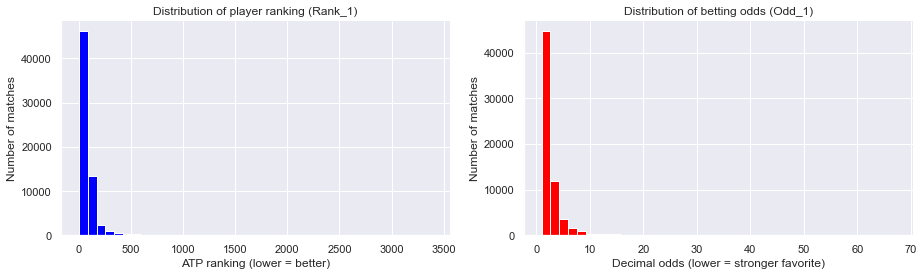

In [435]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(clean["Rank_1"], bins=40, color="blue", edgecolor="white")
axes[0].set_title("Distribution of player ranking (Rank_1)")
axes[0].set_xlabel("ATP ranking (lower = better)")
axes[0].set_ylabel("Number of matches")

axes[1].hist(clean["Odd_1"], bins=40, color="red", edgecolor="white")
axes[1].set_title("Distribution of betting odds (Odd_1)")
axes[1].set_xlabel("Decimal odds (lower = stronger favorite)")
axes[1].set_ylabel("Number of matches")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

Most matches involve players ranked in the top 200 and most odds are close to 1–3, but a small number of matches feature very weak players or extremely high odds. Overall, the betting odds and ranking distributions have a very similar pattern. 

### 5.2 Ranking-points spread (field: Pts_1)

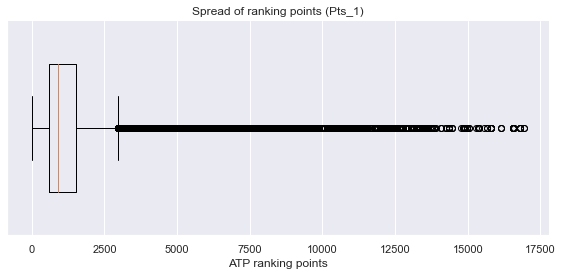

In [464]:
fig, ax = plt.subplots(figsize=(8, 4))

pts_known = clean["Pts_1"].dropna()
ax.boxplot(pts_known, vert=False, widths=0.6)
ax.set_title("Spread of ranking points (Pts_1)")
ax.set_xlabel("ATP ranking points")
ax.set_yticks([])
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

The box (the middle 50% of players) is located near the left, while many dots stretch far to the right. This confirms that a few elite players hold enormous point totals while the majority have small numbers. This is a very uneven distribution.

### 5.3 Ranking versus odds (fields: Rank_1 and Odd_1)

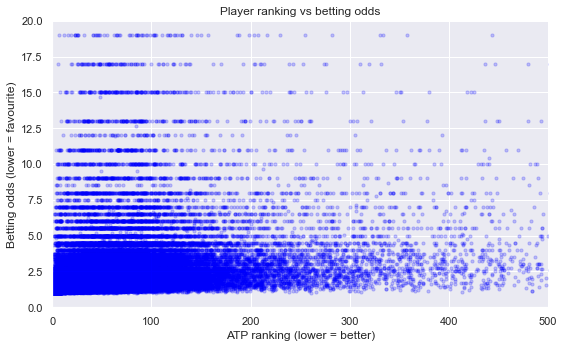

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(clean["Rank_1"], clean["Odd_1"], alpha=0.2, s=10, color="blue")
ax.set_title("Player ranking vs betting odds")
ax.set_xlabel("ATP ranking (lower = better)")
ax.set_ylabel("Betting odds (lower = favorite)")
ax.set_xlim(0, 500)
ax.set_ylim(0, 20)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

There is a clear upward trend, so players with a worse (higher) ranking number tend to have higher odds. This means the bookmakers expect them to lose. This makes sense and shows that rankings and odds carry related information. We will analyze it further. 

## 6. Detailed overview and comparisons

Let's analyze by comparing different columns side by side and checking relations

### 6.1 Odds across surfaces

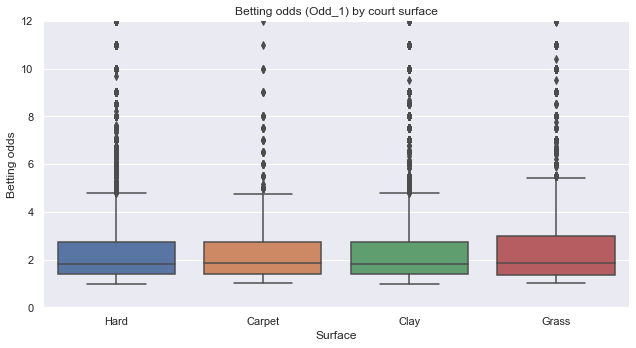

In [479]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=clean, x="Surface", y="Odd_1", ax=ax)
ax.set_title("Betting odds (Odd_1) by court surface")
ax.set_xlabel("Surface")
ax.set_ylabel("Betting odds")
ax.set_ylim(0, 12)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

The median odds and spread are in general similar across Hard, Clay, Grass, and Carpet, which means the surface does not have strong influence on how the bookmakers price a match.

### 6.2 Number of matches per year by surface

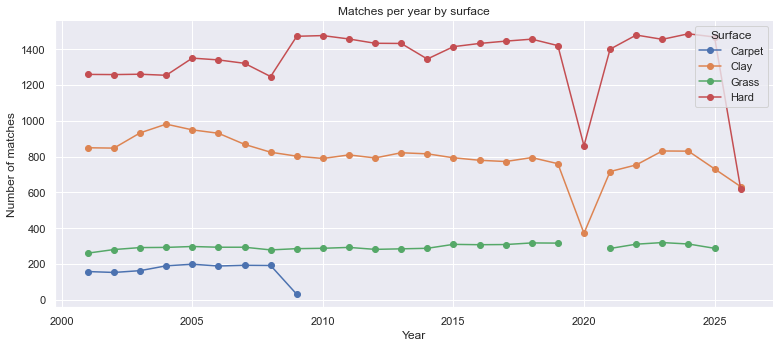

In [491]:
clean["Year"] = clean["Date"].dt.year

by_year_surface = (
    clean.groupby(["Year", "Surface"]).size()
    .reset_index(name="matches")
    .pivot(index="Year", columns="Surface", values="matches")
)

fig, ax = plt.subplots(figsize=(11, 5))
for surface in by_year_surface.columns:
    ax.plot(by_year_surface.index, by_year_surface[surface], marker="o", label=surface)

ax.set_title("Matches per year by surface")
ax.set_xlabel("Year")
ax.set_ylabel("Number of matches")
ax.legend(title="Surface")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

Hard and Clay courts host most matches every year. Thats pretty logical, as almost every tournament including simple ones are played on them. Carpet courts almost disappear after 2009 (carpet was removed from the ATP tour). The final year (2026) is still not ended which is why every line drops down at the end.

### 6.3 Ranking distribution in best-of-3 vs best-of-5 matches

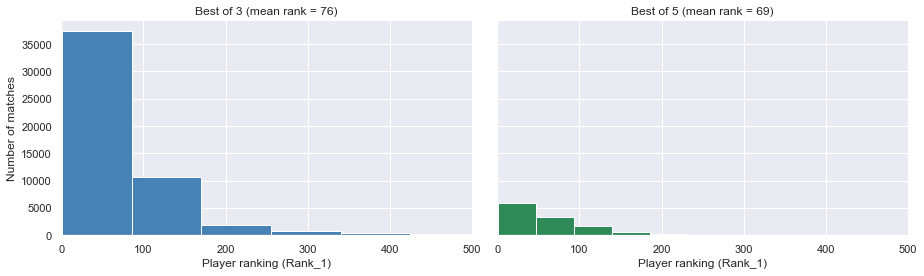

In [492]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)

bo3 = clean[clean["Best of"] == 3]["Rank_1"]
bo5 = clean[clean["Best of"] == 5]["Rank_1"]

axes[0].hist(bo3, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title(f"Best of 3 (mean rank = {bo3.mean():.0f})")
axes[0].set_xlabel("Player ranking (Rank_1)")
axes[0].set_ylabel("Number of matches")

axes[1].hist(bo5, bins=40, color="seagreen", edgecolor="white")
axes[1].set_title(f"Best of 5 (mean rank = {bo5.mean():.0f})")
axes[1].set_xlabel("Player ranking (Rank_1)")

for ax in axes:
    ax.set_xlim(0, 500)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

Best-of-5 matches are only played at Grand Slams which are rarer, and where almost only strong players participate, so their ranking distribution goes toward better (lower) ranks than best-of-3 matches. Lower tournaments are usually best-of-3 matches. Mean ranks in the titles confirm this difference.

### 6.4 Correlation between the numeric fields

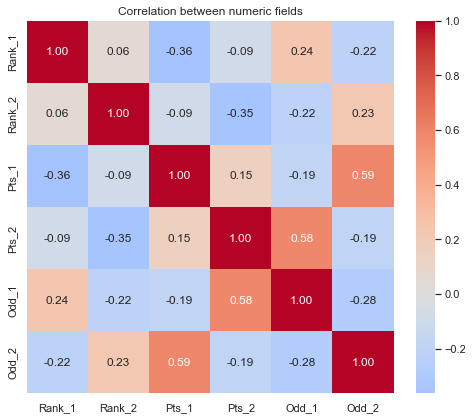

In [502]:
corr_cols = ["Rank_1", "Rank_2", "Pts_1", "Pts_2", "Odd_1", "Odd_2"]
corr = clean[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric fields")
fig.tight_layout()
plt.show()

The heatmap shows the expected patterns: the better (lower) the rank, the lower the odds, and ranking is negatively related to ranking points (better rank goes with more points). We measure the strongest of these relationships precisely later.

## 7. Data transformation — new columns

To make hypothesis tests easuer, we would need more columns for simpler comparisons and analysis

1. **`winner_is_p1`** — `True` when Player 1 was the winner.
2. **`favorite_won`** — `1` if the bookmaker favourite (the player with the lower odds) won.
3. **`higher_rank_won`** — `1` if the better-ranked player (the lower rank) won.
4. **`rank_gap`** — rank gap between the two players' rankings.
5. **`n_sets`** — how many sets were played.

In [511]:
clean["winner_is_p1"] = clean["Winner"] == clean["Player_1"]

fav_is_p1 = clean["Odd_1"] < clean["Odd_2"]
clean["favorite_won"] = np.where(fav_is_p1 == clean["winner_is_p1"], 1, 0)

higher_rank_is_p1 = clean["Rank_1"] < clean["Rank_2"]
clean["higher_rank_won"] = np.where(higher_rank_is_p1 == clean["winner_is_p1"], 1, 0)

clean["rank_gap"] = (clean["Rank_1"] - clean["Rank_2"]).abs()

clean["n_sets"] = clean["Score"].apply(lambda s: len(str(s).split()))

clean[["Player_1", "Player_2", "Winner", "Odd_1", "Odd_2",
       "favorite_won", "Rank_1", "Rank_2", "rank_gap",
       "higher_rank_won", "Score", "n_sets"]].head()

,Player_1,Player_2,Winner,Odd_1,Odd_2,favorite_won,Rank_1,Rank_2,rank_gap,higher_rank_won,Score,n_sets
2876,Haas T.,Smith L.,Haas T.,1.1100,3.750000,1,23.0,485.0,462.0,1,6-3 6-3,2
2877,Hewitt L.,Arthurs W.,Hewitt L.,1.2000,3.550000,1,7.0,83.0,76.0,1,6-4 6-3,2
2890,Goldstein P.,Stoltenberg J.,Stoltenberg J.,2.2100,1.543333,1,81.0,66.0,15.0,1,2-6 2-6,2
2891,Haas T.,Malisse X.,Haas T.,1.2825,2.925000,1,23.0,127.0,104.0,1,7-5 6-3,2
2892,Hewitt L.,Phau B.,Hewitt L.,1.1300,5.500000,1,7.0,208.0,201.0,1,6-7 6-4 6-0,3


New columns turn raw values into the exact numbers our hypotheses are about, for example, whether the favorite won, whether the stronger player won, and how big the difference was.

## 8. Hypothesis checking

### Hypothesis 1 — The betting favourite wins more often than chance, and the size of that edge depends on the court surface.

We test whether favourites win more than 50%, and then we check if the surface influences it

In [538]:
fav_rate = clean["favorite_won"].mean()
wins = clean["favorite_won"].sum()
total = len(clean)
print(f"Favourites won {wins} of {total} matches => win rate {fav_rate:.3f}")

binom = stats.binomtest(wins, total, 0.5, alternative="greater")
print(f"Binomial test vs 50%: p-value = {binom.pvalue:.2e}")

Favourites won 44698 of 64138 matches => win rate 0.697
Binomial test vs 50%: p-value = 0.00e+00


In [ ]:
fav_by_surface = clean.groupby("Surface")["favorite_won"].mean().sort_values(ascending=False)
print("Favorite win rate by surface:")
print(fav_by_surface.round(3))
print()

ct = pd.crosstab(clean["Surface"], clean["favorite_won"])
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print("Contingency table:")
print(ct)
print(f"\nChi-square = {chi2:.2f}, dof = {dof}, p-value = {p_chi:.2e}")

Favourite win rate by surface:
Surface
Grass     0.716
Hard      0.697
Clay      0.693
Carpet    0.672
Name: favorite_won, dtype: float64

Contingency table:
favorite_won      0      1
Surface                   
Carpet          479    980
Clay           6386  14384
Grass          2008   5062
Hard          10567  24272

Chi-square = 18.46, dof = 3, p-value = 3.54e-04


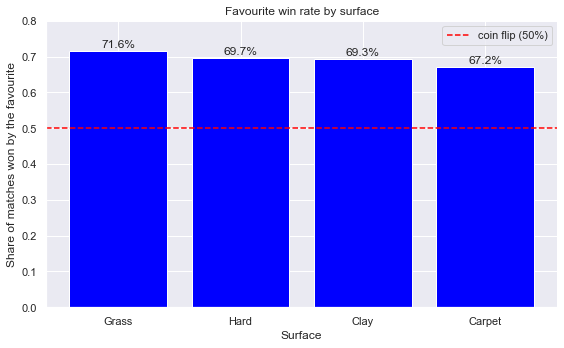

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(fav_by_surface.index, fav_by_surface.values, color="blue", edgecolor="white")
ax.axhline(0.5, color="red", linestyle="--", label="coin flip (50%)")
ax.set_title("Favorite win rate by surface")
ax.set_xlabel("Surface")
ax.set_ylabel("Share of matches won by the favorite")
ax.set_ylim(0, 0.8)
ax.legend()

for i, v in enumerate(fav_by_surface.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

Favorites win about 70% of all matches, far above the 50% line, and the binomial test gives a p-value lofically equal to zero, so favourites clearly win more than chance. The chi-square test on surface gives a very small p-value ( below 0.05), so the favorite's win rate is not identical across surfaces. Looking at the bar chart, favorites do best on Grass (~72%) and slightly worse on Carpet/Clay. So differences between surfaces are small in size, but with so many matches they are real.

**Conclusion:** Hypothesis 1 is correct: favorites win above 50%, and the edge depends just a little bit on the surface (strongest on grass, worst on carpet).

### Hypothesis 2 — A bigger ranking gap makes the stronger player more likely to win, and this effect is stronger in best-of-5 matches than best-of-3.

We look at how the higher-ranked player's win rate changes as the ranking gap grows, and the we check whether longer matches make the result more predictable.

In [ ]:
bins = [0, 10, 30, 60, 100, 5000]
labels = ["0-10", "10-30", "30-60", "60-100", "100+"]
clean["gap_band"] = pd.cut(clean["rank_gap"], bins=bins, labels=labels)

win_by_gap = (
    clean.groupby(["Best of", "gap_band"], observed=True)["higher_rank_won"]
    .mean()
    .unstack("Best of")
)
print("Higher-ranked player's win rate by ranking-gap band:")
print(win_by_gap.round(3))

Higher-ranked player's win rate by ranking-gap band:
Best of       3      5
gap_band              
0-10      0.546  0.580
10-30     0.598  0.652
30-60     0.642  0.718
60-100    0.686  0.782
100+      0.736  0.801


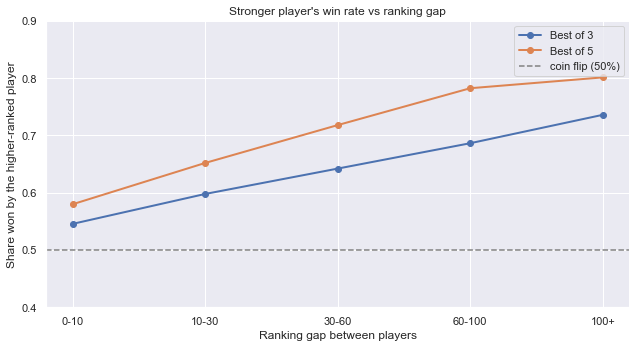

In [557]:
fig, ax = plt.subplots(figsize=(9, 5))
for bo in win_by_gap.columns:
    ax.plot(win_by_gap.index.astype(str), win_by_gap[bo],
            marker="o", linewidth=2, label=f"Best of {bo}")

ax.axhline(0.5, color="gray", linestyle="--", label="coin flip (50%)")
ax.set_title("Stronger player's win rate vs ranking gap")
ax.set_xlabel("Ranking gap between players")
ax.set_ylabel("Share won by the higher-ranked player")
ax.set_ylim(0.4, 0.9)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

In [560]:
big_gap = clean[clean["rank_gap"] > 30]
ct2 = pd.crosstab(big_gap["Best of"], big_gap["higher_rank_won"])
chi2b, p_b, dofb, expb = stats.chi2_contingency(ct2)

rate_bo3 = big_gap[big_gap["Best of"] == 3]["higher_rank_won"].mean()
rate_bo5 = big_gap[big_gap["Best of"] == 5]["higher_rank_won"].mean()
print(f"Large-gap matches (gap > 30):")
print(f" best-of-3 stronger-player win rate: {rate_bo3:.3f}")
print(f" best-of-5 stronger-player win rate: {rate_bo5:.3f}")
print(f" chi-square test p-value: {p_b:.2e}")

Large-gap matches (gap > 30):
 best-of-3 stronger-player win rate: 0.681
 best-of-5 stronger-player win rate: 0.763
 chi-square test p-value: 3.61e-46


Both lines climb steadily from left to right: when two players are close in the rankings (gap 0–10) the stronger player wins only about 55% of the time, but when the gap is huge (100+) they win 73–80% of the time. So the ranking gap does predict the winner.

The best-of-5 line sits above the best-of-3 line at every gap size, and the gap between the two lines becomes larger as the mismatch grows. The chi-square test on large-gap matches confirms the difference between best-of-3 and best-of-5 is significant (p below 0.05). Longer matches give the stronger player more chances to win, so the favourite is harder to upset.

**Conclusion:** Hypothesis 2 is correct — a bigger ranking gap makes the stronger player more likely to win, and that effect is stronger in best-of-5 matches.

## 9. Conclusion

The dataset holds about 68,000 ATP matches from 2000 to 2026. After cleaning up the data, we kept roughly 64,000 matches.

The  plots showed that rankings and odds are closely tied and related — worse-ranked players have higher odds. The comparison charts showed that Hard and Clay dominate the calendar, that carpet courts vanished after 2009, and that best-of-5 matches have stronger players on average.

Both hypotheses held up. First, betting favourites win about 70% of matches, which is far more than a coin flip, and it is slightly surface-dependent, being highest on grass. Second, the bigger the ranking gap, the more reliably the stronger player wins, and this is more likely to happen in best-of-5 matches than best-of-3, because a longer match gives the better player more time.

Overall, the betting market and the ranking system both contain genuine predictive information about match outcomes, and the format of the match (its length) influences how predictable the result is.